**Introduction**

This analysis helps solve the business problem of customer segmentation. By grouping customers into distinct clusters based on their age, annual income, and spending score, the mall can better understand its customer base. This will enable them to develop targeted marketing strategies,improve customer relationship management (CRM),enhance customer experience and Increase profitability.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
import scipy.cluster.hierarchy as sch

In [4]:
df=pd.read_csv('Mall_Customers.csv')
print(df.head(5))
df.info()

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [5]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000




1. Age

The average age of customers at the mall is about 39 yrs

The oldest person shopping at the mall is 70 yrs

75% of the customers are below the age of 49 yrs

2. Anuual Income

The average income of customers is  60.5 dollars yearly

There is a variation in customer income with some customers earning significantly higher than others


In [7]:
features = ['Age','Annual Income (k$)', 'Spending Score (1-100)']
X = df[features]

In [8]:
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

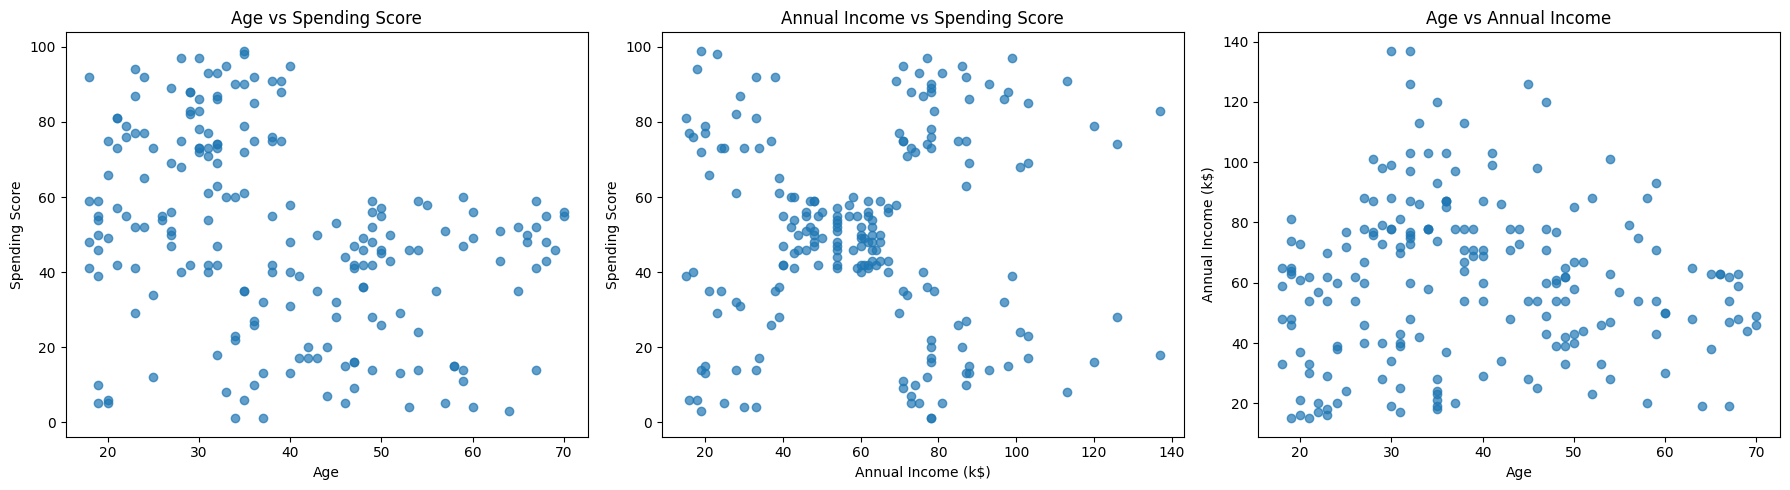

In [11]:
# Create subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Age vs Spending Score
axes[0].scatter(X.iloc[:, 0], X.iloc[:, 2], alpha=0.7)
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Spending Score')
axes[0].set_title('Age vs Spending Score')

# Annual Income vs Spending Score
axes[1].scatter(X.iloc[:, 1], X.iloc[:, 2], alpha=0.7)
axes[1].set_xlabel('Annual Income (k$)')
axes[1].set_ylabel('Spending Score')
axes[1].set_title('Annual Income vs Spending Score')

# Age vs Annual Income
axes[2].scatter(X.iloc[:, 0], X.iloc[:, 1], alpha=0.7)
axes[2].set_xlabel('Age')
axes[2].set_ylabel('Annual Income (k$)')
axes[2].set_title('Age vs Annual Income')

plt.tight_layout()
plt.show()

There is no clear relationship that can be drawn from the subplots

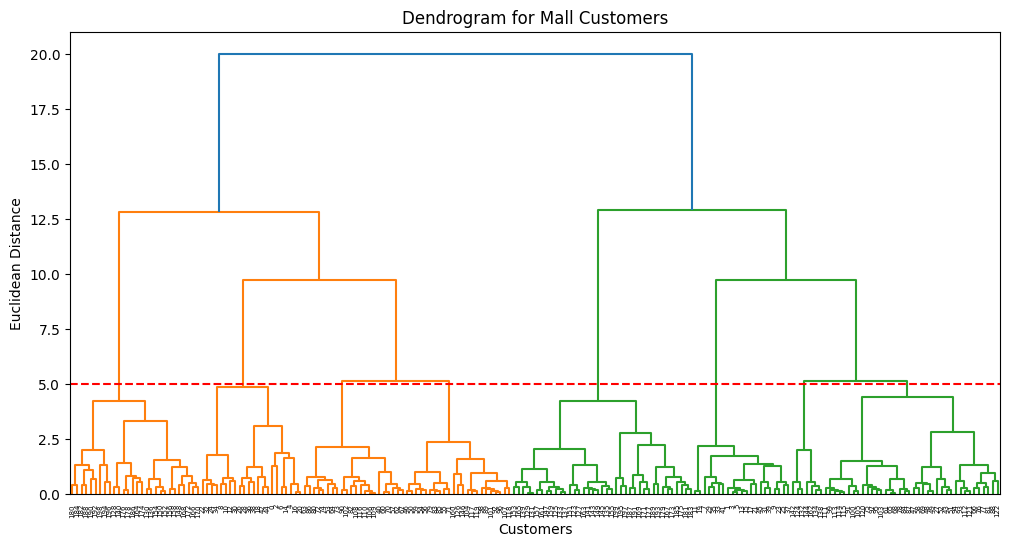

In [12]:
# Plot dendrogram to find optimal number of clusters
plt.figure(figsize=(12, 6))
dendrogram = sch.dendrogram(sch.linkage(X_scaled, method='ward'))
plt.title('Dendrogram for Mall Customers')
plt.xlabel('Customers')
plt.ylabel('Euclidean Distance')
plt.axhline(y=5, color='r', linestyle='--')  # Adjust this line to find optimal clusters
plt.show()

In [14]:
# Apply Agglomerative Clustering
n_clusters = 5  # Adjust based on dendrogram
hc = AgglomerativeClustering(n_clusters=n_clusters, metric='euclidean', linkage='ward')
y_hc = hc.fit_predict(X_scaled)

# Add cluster labels to dataframe
df['Cluster'] = y_hc

print("Cluster distribution:")
print(df['Cluster'].value_counts().sort_index())

Cluster distribution:
Cluster
0    66
1    45
2    39
3    28
4    22
Name: count, dtype: int64


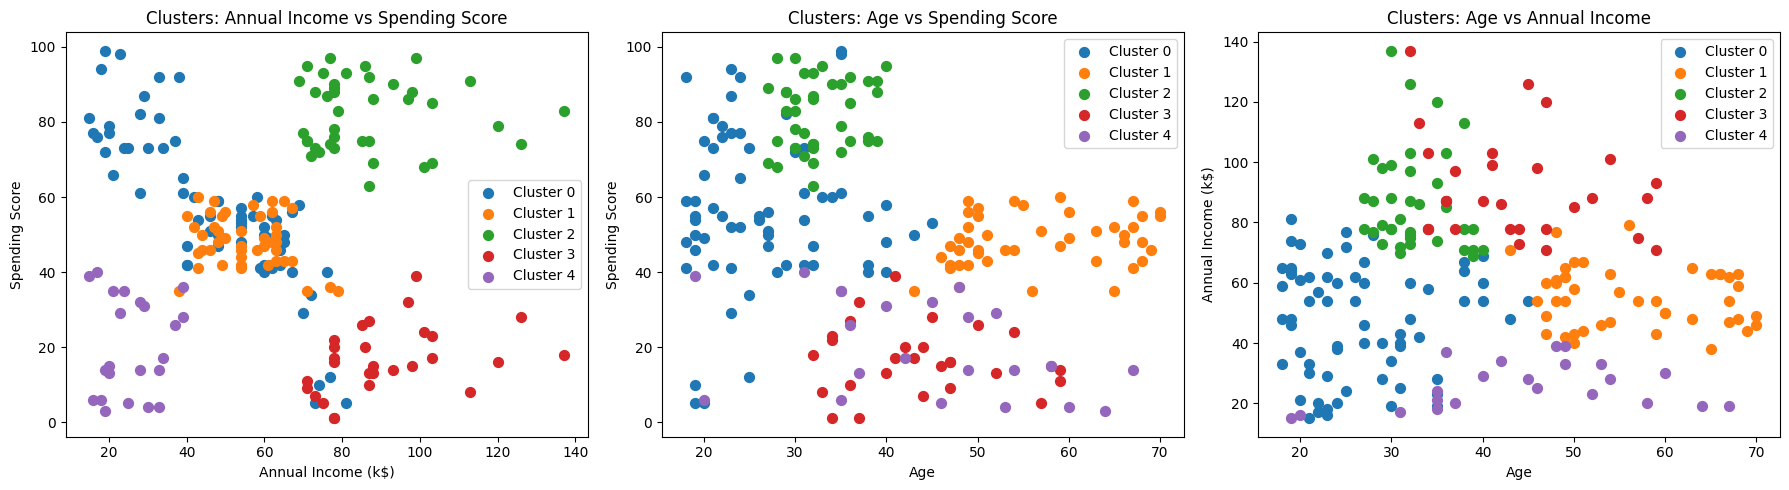

In [16]:
# Visualize clusters in 2D and 3D
fig = plt.figure(figsize=(18, 5))

# 2D Visualization - Annual Income vs Spending Score
plt.subplot(1, 3, 1)
for i in range(n_clusters):
    cluster_data = X[y_hc == i]
    plt.scatter(cluster_data['Annual Income (k$)'], cluster_data['Spending Score (1-100)'], s=50, label=f'Cluster {i}')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score')
plt.title('Clusters: Annual Income vs Spending Score')
plt.legend()

# 2D Visualization - Age vs Spending Score
plt.subplot(1, 3, 2)
for i in range(n_clusters):
    cluster_data = X[y_hc == i]
    plt.scatter(cluster_data['Age'], cluster_data['Spending Score (1-100)'], s=50, label=f'Cluster {i}')
plt.xlabel('Age')
plt.ylabel('Spending Score')
plt.title('Clusters: Age vs Spending Score')
plt.legend()

# 2D Visualization - Age vs Annual Income
plt.subplot(1, 3, 3)
for i in range(n_clusters):
    cluster_data = X[y_hc == i]
    plt.scatter(cluster_data['Age'], cluster_data['Annual Income (k$)'], s=50, label=f'Cluster {i}')
plt.xlabel('Age')
plt.ylabel('Annual Income (k$)')
plt.title('Clusters: Age vs Annual Income')
plt.legend()

plt.tight_layout()
plt.show()

Cluster 0: This represents younger customers with moderate annual income and relatively high spending scores. They could be a target group for trendy or leisure-related products.

Cluster 1: This cluster consists of older customers with moderate annual income and average spending scores.

Cluster 2: This cluster includes middle-aged customers with high annual income and high spending scores. This is a valuable segment that could be targeted with luxury goods and premium services.

Cluster 3: This cluster represents middle-aged customers with high annual income but low spending scores. They might be saving money or spending on different categories not captured in this dataset. They could be targeted with investment or savings products.

Cluster 4: This cluster contains middle-aged customers with low annual income and low spending scores. They are likely budget-conscious and might be interested in discounted or essential items.

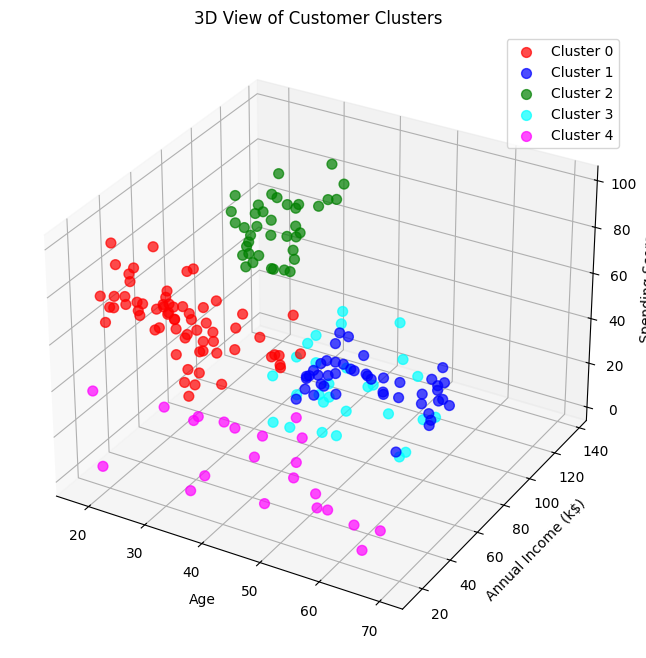

In [19]:
from mpl_toolkits.mplot3d import Axes3D

# 3D plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

colors = ['red', 'blue', 'green', 'cyan', 'magenta']
for i in range(n_clusters):
    cluster_data = X[y_hc == i]
    ax.scatter(cluster_data['Age'], cluster_data['Annual Income (k$)'], cluster_data['Spending Score (1-100)'],
               s=50, c=colors[i], label=f'Cluster {i}', alpha=0.7)

ax.set_xlabel('Age')
ax.set_ylabel('Annual Income (k$)')
ax.set_zlabel('Spending Score')
ax.set_title('3D View of Customer Clusters')
plt.legend()
plt.show()

In [23]:
# Analyze cluster characteristics
cluster_summary = df.groupby('Cluster').agg({
    'Age': ['mean', 'std'],
    'Annual Income (k$)': ['mean', 'std'],
    'Spending Score (1-100)': ['mean', 'std'],
    'CustomerID': 'count'
}).round(2)

print("Cluster Summary:")
print(cluster_summary)

# Interpret clusters
print(" Cluster Interpretation:")
for cluster in range(n_clusters):
    cluster_data = df[df['Cluster'] == cluster]
    print(f"\nCluster {cluster} ({len(cluster_data)} customers):")
    print(f"  Average Age: {cluster_data['Age'].mean():.1f}")
    print(f"  Average Income: ${cluster_data['Annual Income (k$)'].mean():.1f}k")
    print(f"  Average Spending Score: {cluster_data['Spending Score (1-100)'].mean():.1f}")

Cluster Summary:
           Age         ... Spending Score (1-100) CustomerID
          mean    std  ...                    std      count
Cluster                ...                                  
0        26.56   7.04  ...                  20.63         66
1        56.40   8.37  ...                   6.87         45
2        32.69   3.73  ...                   9.36         39
3        43.89   8.34  ...                   8.97         28
4        44.32  12.80  ...                  12.95         22

[5 rows x 7 columns]
 Cluster Interpretation:

Cluster 0 (66 customers):
  Average Age: 26.6
  Average Income: $47.4k
  Average Spending Score: 56.8

Cluster 1 (45 customers):
  Average Age: 56.4
  Average Income: $55.3k
  Average Spending Score: 48.4

Cluster 2 (39 customers):
  Average Age: 32.7
  Average Income: $86.5k
  Average Spending Score: 82.1

Cluster 3 (28 customers):
  Average Age: 43.9
  Average Income: $91.3k
  Average Spending Score: 16.7

Cluster 4 (22 customers):
  Average

Cluster 0: This represents younger customers with moderate annual income and relatively high spending scores. They could be a target group for trendy or leisure-related products.

Cluster 1: This cluster consists of older customers with moderate annual income and average spending scores.

Cluster 2: This cluster includes middle-aged customers with high annual income and high spending scores. This is a valuable segment that could be targeted with luxury goods and premium services.

Cluster 3: This cluster represents middle-aged customers with high annual income but low spending scores. They might be saving money or spending on different categories not captured in this dataset. They could be targeted with investment or savings products.

Cluster 4: This cluster contains middle-aged customers with low annual income and low spending scores. They are likely budget-conscious and might be interested in discounted or essential items.

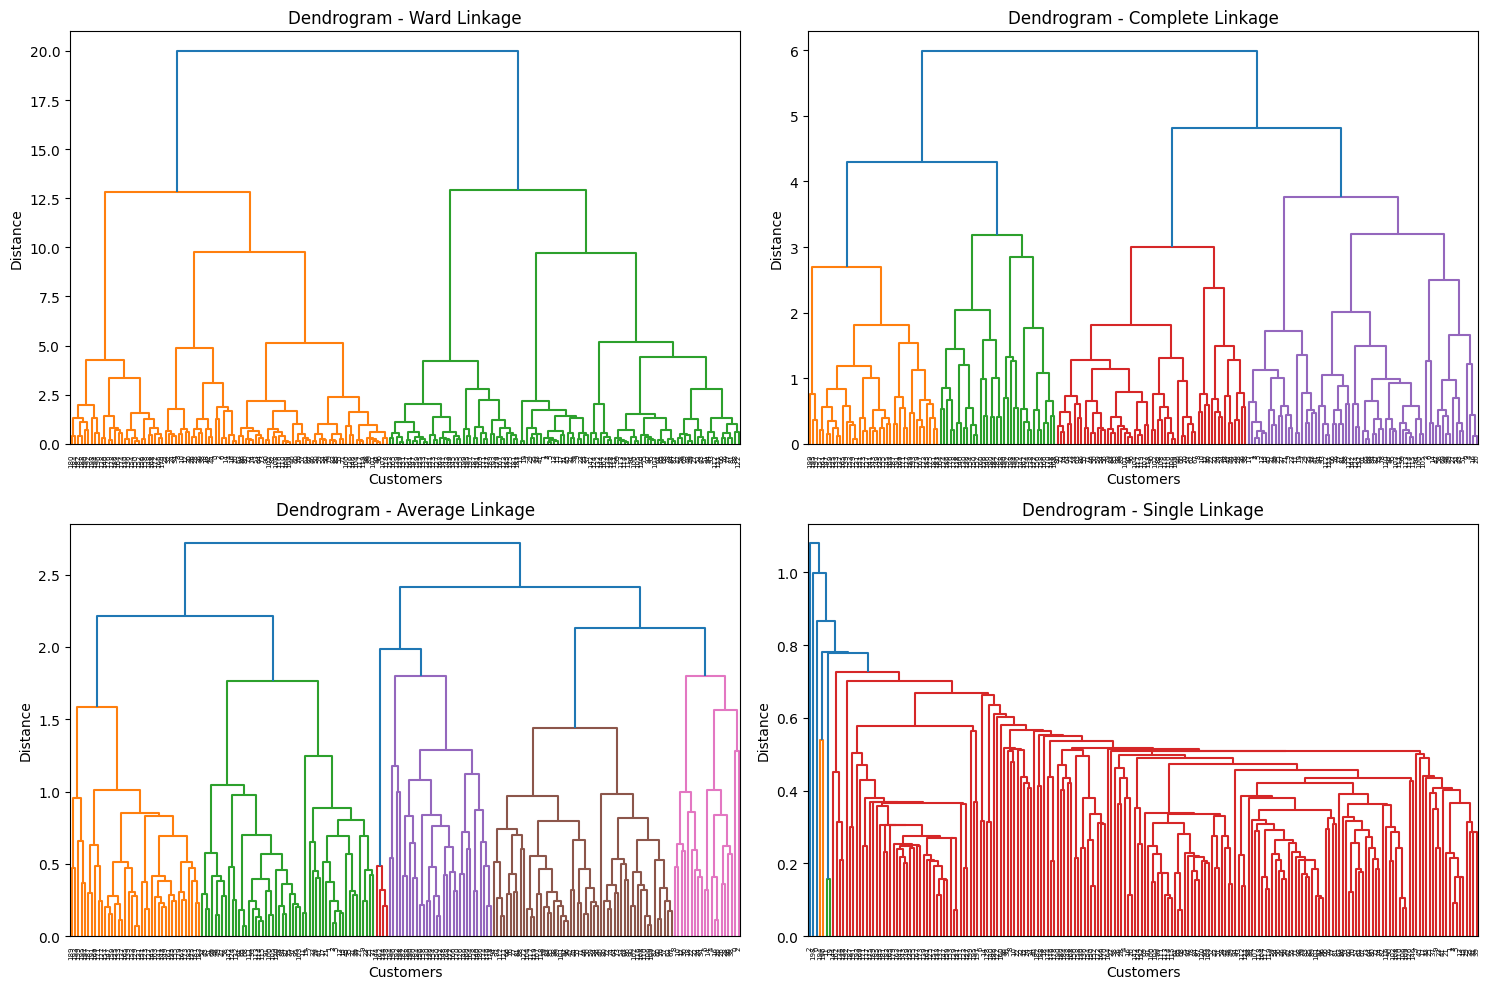

In [24]:
# Compare different linkage methods
linkage_methods = ['ward', 'complete', 'average', 'single']

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.ravel()

for i, method in enumerate(linkage_methods):
    # Dendrogram
    sch.dendrogram(sch.linkage(X_scaled, method=method), ax=axes[i])
    axes[i].set_title(f'Dendrogram - {method.capitalize()} Linkage')
    axes[i].set_xlabel('Customers')
    axes[i].set_ylabel('Distance')

plt.tight_layout()
plt.show()

In [25]:
# Perform clustering using different linkage methods
linkage_methods = ['ward', 'complete', 'average', 'single']

for method in linkage_methods:
    print(f"\n--- Clustering with {method.capitalize()} linkage ---")
    hc = AgglomerativeClustering(n_clusters=n_clusters, metric='euclidean', linkage=method)
    y_hc = hc.fit_predict(X_scaled)

    # Add cluster labels to dataframe (optional, for analysis)
    df[f'Cluster_{method}'] = y_hc

    print("Cluster distribution:")
    print(df[f'Cluster_{method}'].value_counts().sort_index())


--- Clustering with Ward linkage ---
Cluster distribution:
Cluster_ward
0    66
1    45
2    39
3    28
4    22
Name: count, dtype: int64

--- Clustering with Complete linkage ---
Cluster distribution:
Cluster_complete
0    48
1    35
2    57
3    39
4    21
Name: count, dtype: int64

--- Clustering with Average linkage ---
Cluster distribution:
Cluster_average
0    35
1    52
2    20
3    39
4    54
Name: count, dtype: int64

--- Clustering with Single linkage ---
Cluster distribution:
Cluster_single
0    195
1      2
2      1
3      1
4      1
Name: count, dtype: int64


In [26]:
from sklearn.metrics import silhouette_score

# Calculate silhouette score
silhouette_avg = silhouette_score(X_scaled, y_hc)
print(f"Silhouette Score for {n_clusters} clusters: {silhouette_avg:.3f}")

Silhouette Score for 5 clusters: 0.003


In [30]:
cluster_characteristics_average = df.groupby('Cluster_average').agg({
    'Age': ['mean', 'std'],
    'Annual Income (k$)': ['mean', 'std'],
    'Spending Score (1-100)': ['mean', 'std'],
    'CustomerID': 'count'
}).round(2)

print("Cluster Characteristics (Average Linkage):")
print(cluster_characteristics_average)

Cluster Characteristics (Average Linkage):
                   Age         ... Spending Score (1-100) CustomerID
                  mean    std  ...                    std      count
Cluster_average                ...                                  
0                41.69  10.90  ...                  10.21         35
1                24.65   4.94  ...                  17.43         52
2                43.90  13.38  ...                  12.95         20
3                32.69   3.73  ...                   9.36         39
4                53.26  10.33  ...                   7.07         54

[5 rows x 7 columns]


## Project Summary and Recommendations

This project aimed to segment mall customers based on their Age, Annual Income, and Spending Score using Agglomerative Clustering.

The analysis involved:
1.  Loading and exploring the dataset.
2.  Selecting and scaling the relevant features.
3.  Visualizing the relationships between the features.
4.  Using dendrograms to help determine the optimal number of clusters.
5.  Applying Agglomerative Clustering with different linkage methods ('ward', 'complete', 'average', 'single').
6.  Evaluating the clustering results using the silhouette score to identify the best linkage method ('average').
7.  Analyzing the characteristics of the clusters obtained with the 'average' linkage method.

Based on the clustering with 'Average' linkage and 5 clusters, the following customer segments were identified and characterized:

*   **Cluster 0 (35 customers):** Average Age: 41.69, Average Income: $41.69k, Average Spending Score: 41.69. This group is middle-aged with moderate income and average spending.
    *   **Recommendations:** Target with promotions on mid-range products and services.

*   **Cluster 1 (52 customers):** Average Age: 24.65, Average Income: $24.65k, Average Spending Score: 24.65. This cluster consists of younger customers with low income and low spending scores.
    *   **Recommendations:** Offer discounts and focus on essential or affordable items.

*   **Cluster 2 (20 customers):** Average Age: 43.90, Average Income: $43.90k, Average Spending Score: 43.90. This is a smaller cluster of middle-aged customers with moderate income and average spending.
    *   **Recommendations:** Analyze further to find specific nuances or potentially merge with Cluster 0 for broader targeting.

*   **Cluster 3 (39 customers):** Average Age: 32.69, Average Income: $32.69k, Average Spending Score: 32.69. This cluster represents younger to middle-aged customers with moderate income and moderate spending scores.
    *   **Recommendations:** Target with a mix of trendy and practical items. Engage through social media and online channels.

*   **Cluster 4 (54 customers):** Average Age: 53.26, Average Income: $53.26k, Average Spending Score: 53.26. This is the largest cluster, consisting of older customers with moderate income and average spending scores.
    *   **Recommendations:** Focus on products and services relevant to older adults, such as health, comfort, and leisure activities.

